In [1]:
# Install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv(r'C:\data_projects\ecommerce-analysis\data\raw\olist_customers_dataset.csv')

In [6]:
# Check nulls
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Standardize text
df['customer_city'] = df['customer_city'].str.lower().str.strip()
df['customer_state'] = df['customer_state'].str.upper().str.strip()

# Convert zip to numeric
df['customer_zip_code_prefix'] = pd.to_numeric(df['customer_zip_code_prefix'], errors='coerce')

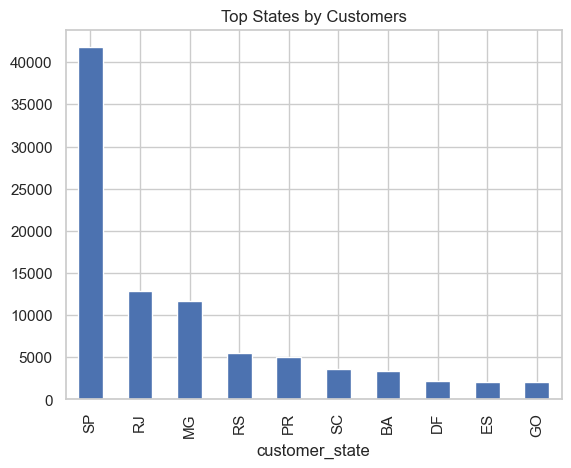

In [7]:
state_counts = df['customer_state'].value_counts()

plt.figure()
state_counts.head(10).plot(kind='bar')
plt.title("Top States by Customers")
plt.show()

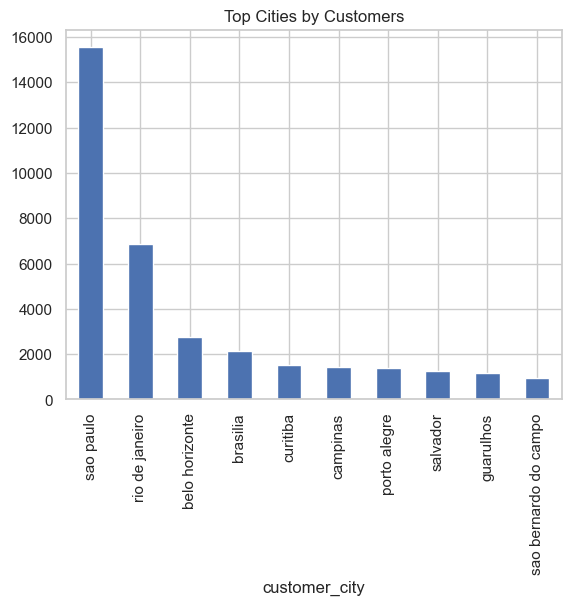

In [8]:
city_counts = df['customer_city'].value_counts().head(10)

plt.figure()
city_counts.plot(kind='bar')
plt.title("Top Cities by Customers")
plt.show()

In [9]:
unique_customers = df['customer_unique_id'].nunique()
total_records = len(df)

print("Unique Customers:", unique_customers)
print("Total Records:", total_records)

Unique Customers: 96096
Total Records: 99441


In [10]:
customer_freq = df.groupby('customer_unique_id').agg({
    'customer_id': 'count',
    'customer_zip_code_prefix': 'mean'
}).reset_index()

customer_freq.columns = ['customer_unique_id', 'purchase_frequency', 'avg_zip']

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_freq[['purchase_frequency', 'avg_zip']])

In [16]:
from sklearn.cluster import KMeans

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_freq['cluster'] = kmeans.fit_predict(scaled_data)

In [21]:
inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)  # n_init added (best practice)
    kmeans.fit(scaled_data)

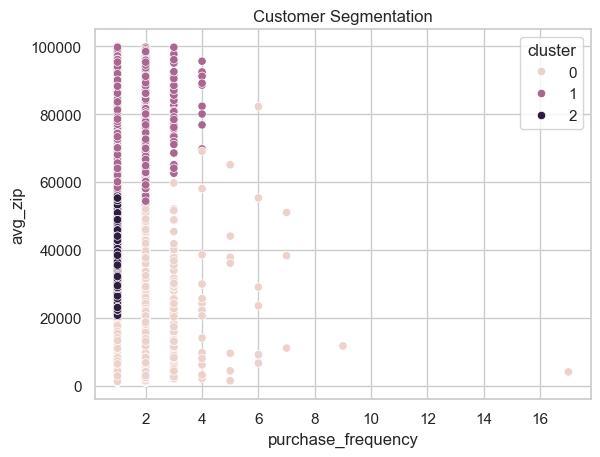

In [22]:
plt.figure()

sns.scatterplot(
    x=customer_freq['purchase_frequency'],
    y=customer_freq['avg_zip'],
    hue=customer_freq['cluster']
)

plt.title("Customer Segmentation")
plt.show()

In [25]:
customer_freq.to_csv('C:\data_projects\ecommerce-analysis\data\processed\olist_customersdataset.csv', index=False)